In [3]:
%pip install kaggle pandas matplotlib seaborn --quiet 
import os 
# Ensure Kaggle directory exists 
kaggle_dir = os.path.expanduser("~/.kaggle") 
if not os.path.exists(kaggle_dir): 
    os.makedirs(kaggle_dir) 
# Download and unzip the dataset 
!kaggle datasets download -d kunalgp/top-1000-most-played-spotify-songs-of-all-time -p ./spotify_dataset --unzip 
# Confirm download 
print("Files in directory:", os.listdir("./spotify_dataset"))

Note: you may need to restart the kernel to use updated packages.
Dataset URL: https://www.kaggle.com/datasets/kunalgp/top-1000-most-played-spotify-songs-of-all-time
License(s): CC0-1.0

Files in directory: ['spotify_top_1000_tracks.csv']



  0%|          | 0.00/52.0k [00:00<?, ?B/s]
100%|██████████| 52.0k/52.0k [00:00<00:00, 344kB/s]
100%|██████████| 52.0k/52.0k [00:00<00:00, 342kB/s]


In [5]:
import pandas as pd
import os

# FIX: Point this to the CSV file, not the kaggle.json
dataset_path = r"C:\Users\CLienT\Documents\COMPROG LAB\spotify_top_1000_tracks.csv"

# Load dataset
df = pd.read_csv(dataset_path, encoding="utf-8")

# Now these lines will work because the CSV has 'release_date'
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

print("Dataset loaded and basic preprocessing complete!")
print(df.head(3))

Dataset loaded and basic preprocessing complete!
                 track_name          artist  \
0  All The Stars (with SZA)  Kendrick Lamar   
1                   Starboy      The Weeknd   
2                  Señorita    Shawn Mendes   

                                               album release_date  popularity  \
0  Black Panther The Album Music From And Inspire...   2018-02-09          95   
1                                            Starboy   2016-11-25          90   
2                                           Señorita   2019-06-21          80   

                                         spotify_url                      id  \
0  https://open.spotify.com/track/3GCdLUSnKSMJhs4...  3GCdLUSnKSMJhs4Tj6CV3s   
1  https://open.spotify.com/track/7MXVkk9YMctZqd1...  7MXVkk9YMctZqd1Srtv4MB   
2  https://open.spotify.com/track/0TK2YIli7K1leLo...  0TK2YIli7K1leLovkQiNik   

   duration_min    year  
0      3.869767  2018.0  
1      3.840883  2016.0  
2      3.182667  2019.0  


In [5]:
import numpy as np 
# Clean up text columns 
df['track_name'] = df['track_name'].str.strip() 
df['artist'] = df['artist'].str.strip() 
df['album'] = df['album'].str.strip() 
# Convert 'year' to integer 
df['year'] = df['year'].fillna(0).astype(int)
# Drop unnecessary columns 
cols_to_drop = ['spotify_url', 'id', 'release_date'] 
 
# Check for and add other common audio feature columns if they exist 
if 'time_signature' in df.columns: 
    cols_to_drop.append('time_signature') 
if 'key' in df.columns: 
    cols_to_drop.append('key') 
if 'mode' in df.columns: 
    cols_to_drop.append('mode') 
 
df = df.drop(columns=cols_to_drop, errors='ignore') 
 
# Feature Engineering: Tempo Category 
tempo_bins = [0, 100, 140, np.inf] 
tempo_labels = ['Slow', 'Medium', 'Fast'] 
 
if 'tempo' in df.columns: 
    df['tempo_category'] = pd.cut(  # Create tempo category column 
        df['tempo'], bins=tempo_bins,  
        labels=tempo_labels, right=False 
    ) 
    print("Feature 'tempo_category' created.") 
else: 
    print("Warning: 'tempo' column not found; skipping 'tempo_category' creation.") 
    # Remove duplicates 
df = df.drop_duplicates(subset=['track_name', 'artist'], keep='first') 
 
print(f"   Data cleaning and feature engineering complete.") 
print(f"Final Row Count after deduplication: {len(df)}") 

   Data cleaning and feature engineering complete.
Final Row Count after deduplication: 971


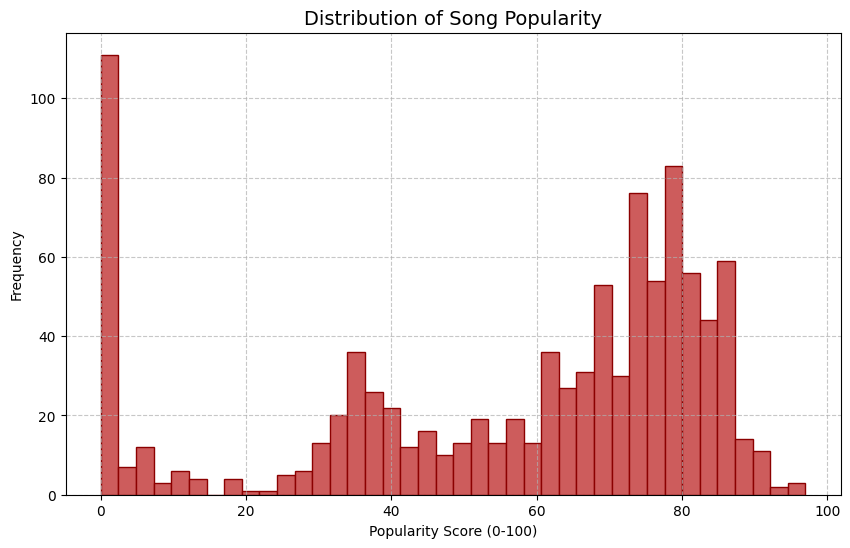

In [6]:
# histogram
import matplotlib.pyplot as plt 
 
plt.figure(figsize=(10, 6)) 
plt.hist(df['popularity'], bins=40, color='indianred', 
edgecolor='darkred') 
plt.title('Distribution of Song Popularity', fontsize=14) 
plt.xlabel('Popularity Score (0-100)') 
plt.ylabel('Frequency') 
plt.grid(True, linestyle='--', alpha=0.7) 
plt.show() 

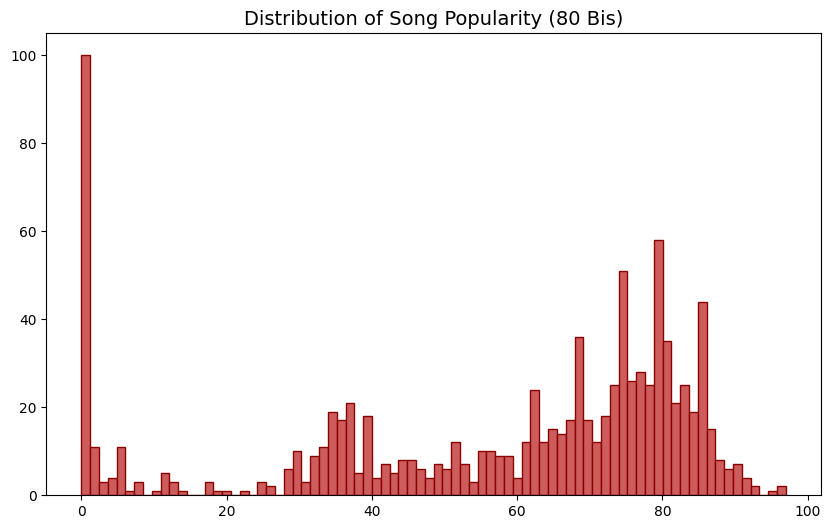

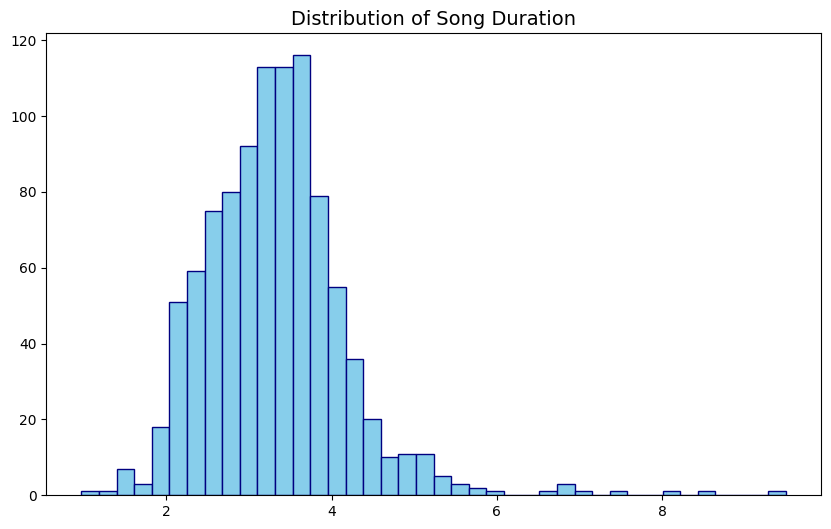

In [7]:
# Try It
plt.figure(figsize=(10, 6))
plt.hist(df['popularity'], bins=80, color='indianred', edgecolor='darkred')
plt.title('Distribution of Song Popularity (80 Bis)', fontsize=14)
plt.show()

# Try It: Replace 'duration_min' with 'popularity' 
plt.figure(figsize=(10, 6))
plt.hist(df['duration_min'], bins=40, color='skyblue', edgecolor='navy') 
plt.title('Distribution of Song Duration', fontsize=14)
plt.show()

C:\Users\CLienT\AppData\Local\Temp\ipykernel_14040\3754510795.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='popularity', data = df, palette='viridis')


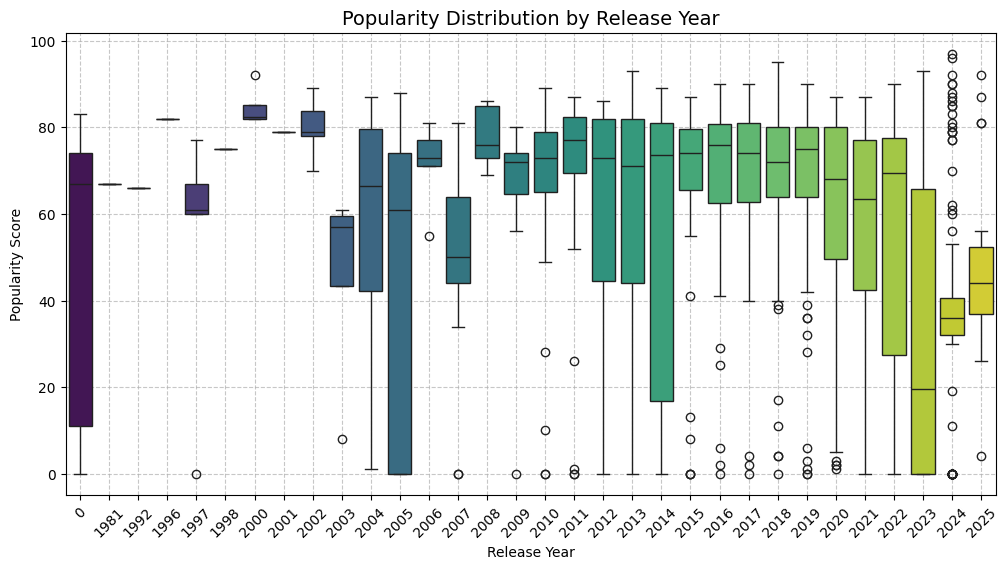

In [8]:
# boxplot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(x='year', y='popularity', data = df, palette='viridis')
plt.title('Popularity Distribution by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Popularity Score')
plt.xticks(rotation = 45)
plt.grid(True, linestyle='--', alpha = 0.7)
plt.show()

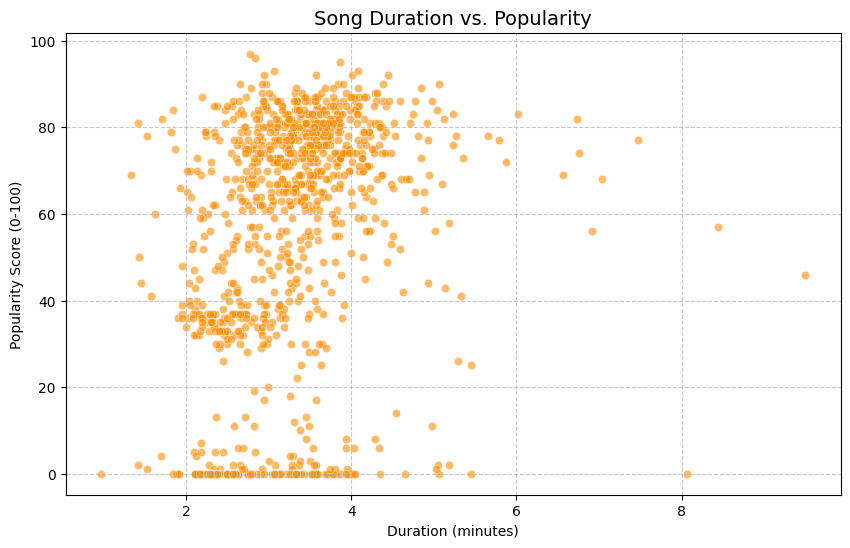

In [9]:
# scatter plot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_min',
 y='popularity',
 data = df,
 color='darkorange',
 alpha = 0.6)
plt.title('Song Duration vs. Popularity', fontsize = 14)
plt.xlabel('Duration (minutes)')
plt.ylabel('Popularity Score (0-100)')
plt.grid(True, linestyle='--', alpha = 0.7)
plt.show()

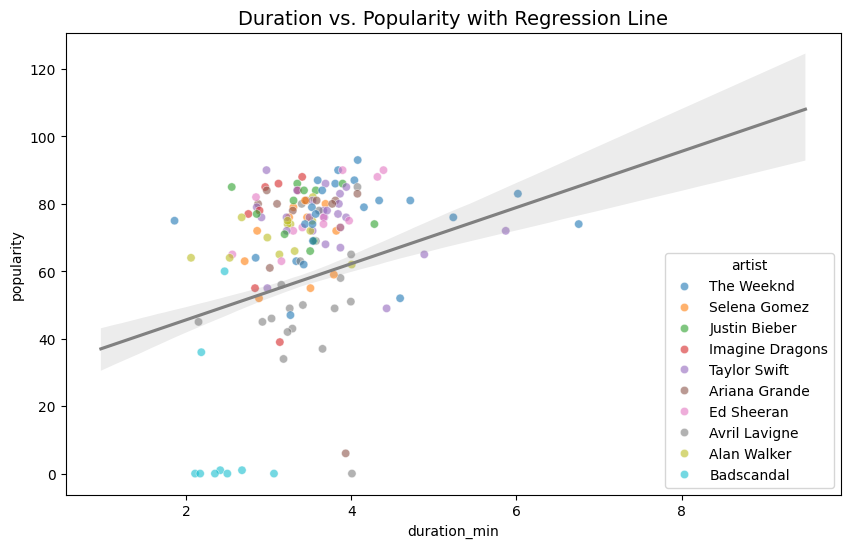

In [10]:
# Try It
plt.figure(figsize=(10, 6))
# Using a sample of the data (e.g., top 10 artists) for the hue to keep it readable
top_artists = df['artist'].value_counts().head(10).index
df_subset = df[df['artist'].isin(top_artists)]

sns.scatterplot(x='duration_min', y='popularity', hue='artist', data=df_subset, alpha=0.6)
sns.regplot(x='duration_min', y='popularity', data=df, scatter=False, color='grey')
plt.title('Duration vs. Popularity with Regression Line', fontsize=14)
plt.show()

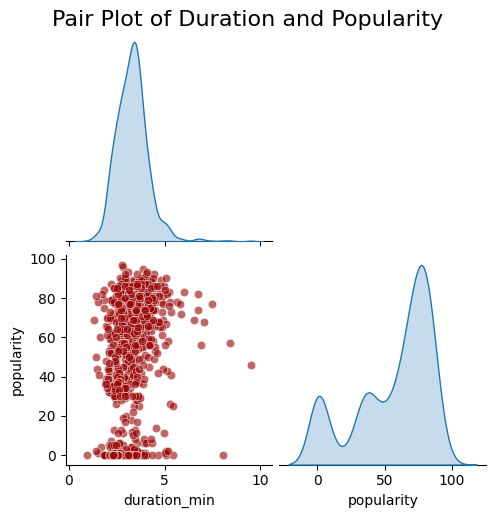

In [11]:
# pair plot
import matplotlib.pyplot as plt
import seaborn as sns
# Using only the confirmed numerical columns: 'duration_min' and 'popularity'
key_features = ['duration_min', 'popularity']
# We use the simplified sns.pairplot function
sns.pairplot(
 df[key_features],
 diag_kind='kde',
 corner=True,
 plot_kws={'alpha': 0.6, 'color': '#990000'}
)
plt.suptitle('Pair Plot of Duration and Popularity', y=1.02, fontsize = 16)
plt.show()

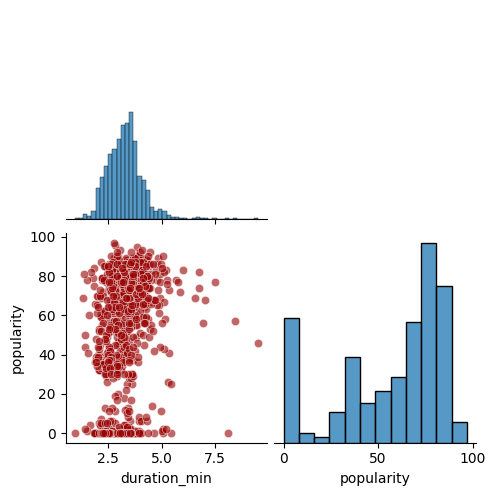

In [12]:
# Try It
sns.pairplot(
    df[['duration_min', 'popularity']], 
    diag_kind='hist', # Changed from 'kde' 
    corner=True,
    plot_kws={'alpha': 0.6, 'color': '#990000'}
)
plt.show()

<Figure size 800x800 with 0 Axes>

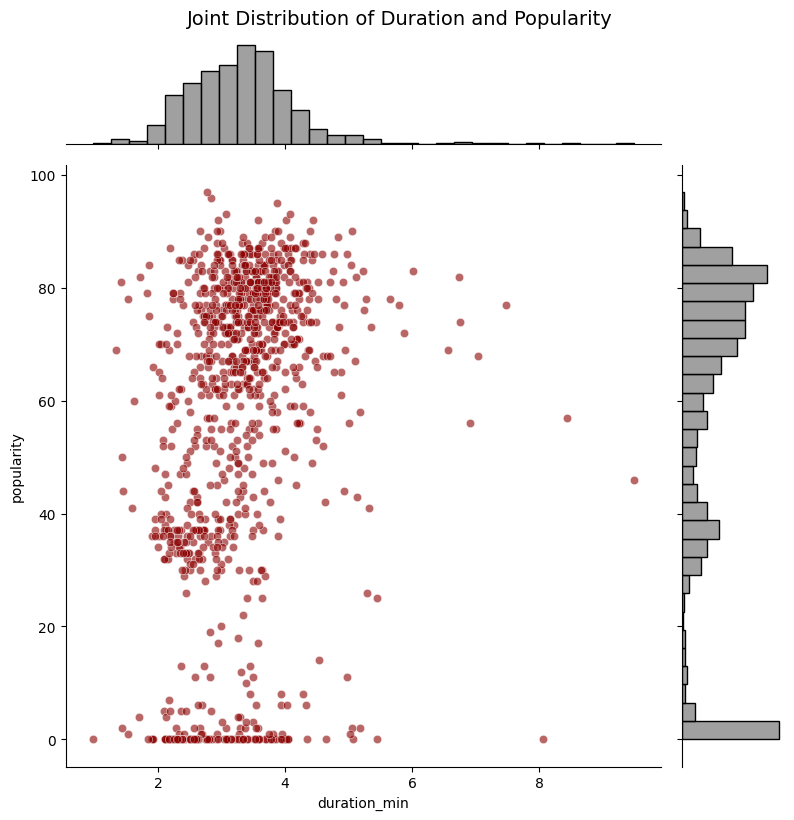

In [13]:
# joint plot
import matplotlib.pyplot as plt 
import seaborn as sns 
 
plt.figure(figsize=(8, 8)) 
sns.jointplot( 
    x='duration_min',  
    y='popularity',  
    data=df,  
    kind='scatter',  # Use 'scatter' for the central plot type 
    height=8,        # Controls the overall size of the plot 
    marginal_kws={'bins': 30, 'color': 'gray', 'edgecolor': 'black'}, 
    joint_kws={'alpha': 0.6, 'color': 'darkred'} 
) 
 
plt.suptitle('Joint Distribution of Duration and Popularity', y=1.02, 
fontsize=14) 
plt.show() 

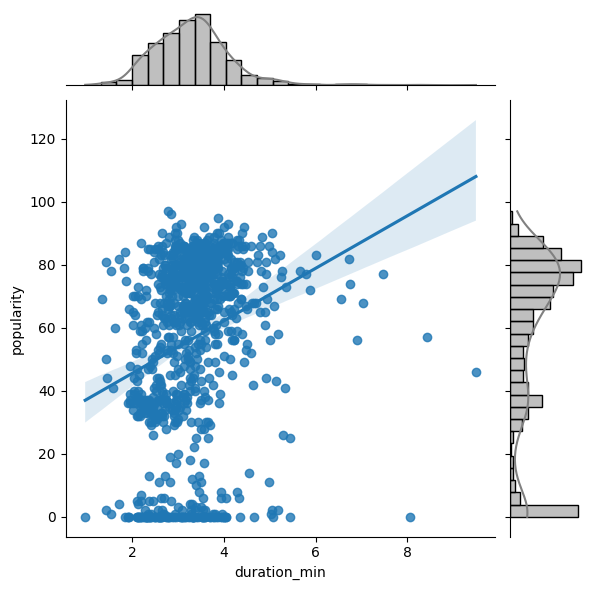

In [14]:
# Try It 
sns.jointplot(
    x='duration_min', 
    y='popularity', 
    data=df, 
    kind='reg',
    marginal_kws=dict(bins=25, color='gray') 
)
plt.show()

In [26]:
# animated line chart

# Requirements:
# pip install matplotlib pillow pandas
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser
# Step 1: Load Dataset
csv_files = r"C:\Users\CLienT\Documents\COMPROG LAB\spotify_top_1000_tracks.csv"
df = pd.read_csv(csv_files)
# Step 2: Data Preparation
df ['release_date'] = pd.to_datetime(df ['release_date'], errors='coerce')
df['year'] = df ['release_date'].dt.year
df = df.dropna(subset=['year'])
# Compute average popularity per year
yearly_popularity = df.groupby('year') ['popularity'].mean().reset_index()
yearly_popularity = yearly_popularity.sort_values('year')
# Step 3: Initialize the Figure
fig, ax = plt.subplots (figsize=(10,6))
ax.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax.set_ylim(0, yearly_popularity ['popularity'].max() * 1.1)
line, = ax.plot([], [], color='royalblue', linewidth = 2.5, label='Average Popularity')
ax.set_title("Evolution of Track Popularity Over Time", fontsize = 14, color='navy')
ax.set_xlabel("Year of Release", fontsize = 12)
ax.set_ylabel("Average Popularity", fontsize = 12)
ax.legend(loc="upper left")
plt.tight_layout()
#--- Step 4: Define Animation Function
def animate(i):
 x = yearly_popularity['year'][:i]
 y = yearly_popularity['popularity'][:i]
 line.set_data(x, y)
 return line,
# Step 5: Create and Save Animation
ani = FuncAnimation (fig, animate, frames=len(yearly_popularity), interval = 100,
 repeat=False)
# Automatically Save the GIF
gif_path = os.path.abspath("yearly_popularity_trend.gif")
ani.save(gif_path, writer=PillowWriter(fps=10))
print(f" GIF saved successfully at: {gif_path}")
# Step 6: Open the Saved GIF
webbrowser.open(f"file://{gif_path}") # Opens the saved GIF automatically
plt.close(fig)

 GIF saved successfully at: c:\Users\CLienT\Documents\COMPROG LAB\Lab7_DataVisualization_Salahop\yearly_popularity_trend.gif


In [10]:
# Try It
# pip install matplotlib pillow pandas
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import webbrowser
# Step 1: Load Dataset
csv_files = r"C:\Users\CLienT\Documents\COMPROG LAB\spotify_top_1000_tracks.csv"
df = pd.read_csv(csv_files)
# Step 2: Data Preparation
df ['release_date'] = pd.to_datetime(df ['release_date'], errors='coerce')
df['year'] = df ['release_date'].dt.year
df = df.dropna(subset=['year'])
# Compute average popularity per year
yearly_popularity = df.groupby('year') ['popularity'].mean().reset_index()
yearly_popularity = yearly_popularity.sort_values('year')
# Step 3: Initialize the Figure
fig, ax = plt.subplots (figsize=(10,6))
ax.set_xlim(yearly_popularity['year'].min(), yearly_popularity['year'].max())
ax.set_ylim(0, yearly_popularity ['popularity'].max() * 1.1)
line, = ax.plot([], [], color='royalblue', linewidth = 2.5, label='Average Popularity')
ax.set_title("Evolution of Track Popularity Over Time", fontsize = 14, color='navy')
ax.set_xlabel("Year of Release", fontsize = 12)
ax.set_ylabel("Average Popularity", fontsize = 12)
ax.legend(loc="upper left")
plt.tight_layout()
#--- Step 4: Define Animation Function
def animate(i):
 x = yearly_popularity['year'][:i]
 y = yearly_popularity['popularity'][:i]
 line.set_data(x, y)
 return line,
# Step 5: Create and Save Animation
ani = FuncAnimation(fig, animate, frames=len(yearly_popularity), interval=60, 
repeat=False) 
# Automatically Save the GIF
gif_path = os.path.abspath("yearly_popularity_fast.gif")
ani.save(gif_path, writer=PillowWriter(fps=10))
print(f" GIF saved successfully at: {gif_path}")
# Step 6: Open the Saved GIF
webbrowser.open(f"file://{gif_path}") # Opens the saved GIF automatically
plt.close(fig)

 GIF saved successfully at: c:\Users\CLienT\Documents\COMPROG LAB\Lab7_DataVisualization_Salahop\yearly_popularity_fast.gif


In [9]:
# DATA AND OBSERVATION
#0
import pandas as pd  
import matplotlib.pyplot as plt 
import seaborn as sns 
 
student_name = "Reynald Salahop" 
student_id = "4175"  
 
id_num = int(student_id[-3:]) 
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) 
% 256:02x}" 
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) 
% 256:02x}"

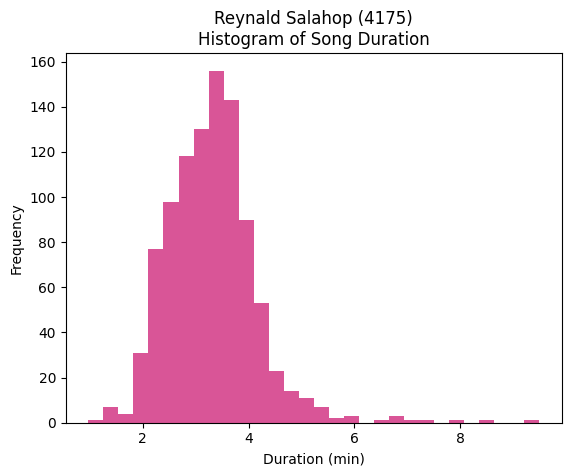

In [18]:
#1
df['duration_min'].plot(kind='hist', bins=30, color=color1, alpha=0.7) 
plt.title(f"{student_name} ({student_id})\nHistogram of Song Duration") 
plt.xlabel('Duration (min)') 
plt.ylabel('Frequency') 
plt.show()

C:\Users\CLienT\AppData\Local\Temp\ipykernel_17684\3808421819.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm')


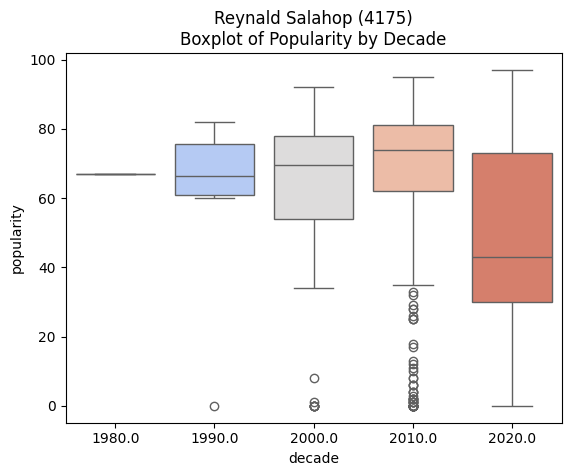

In [14]:
#2
df['decade'] = (df['year'] // 10) * 10
sns.boxplot(x='decade', y='popularity', data=df, palette='coolwarm') 
plt.title(f"{student_name} ({student_id})\nBoxplot of Popularity by Decade") 
plt.show()

C:\Users\CLienT\AppData\Local\Temp\ipykernel_14040\3443954103.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='artist', data=df,


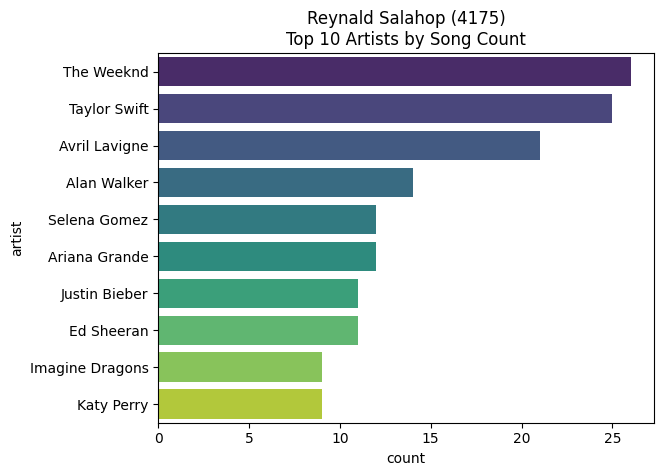

In [20]:
#3
sns.countplot(y='artist', data=df, 
order=df['artist'].value_counts().head(10).index, palette='viridis') 
plt.title(f"{student_name} ({student_id})\nTop 10 Artists by Song Count") 
plt.show()

C:\Users\CLienT\AppData\Local\Temp\ipykernel_11136\3084227728.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm', scale='width')
C:\Users\CLienT\AppData\Local\Temp\ipykernel_11136\3084227728.py:6: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm', scale='width')


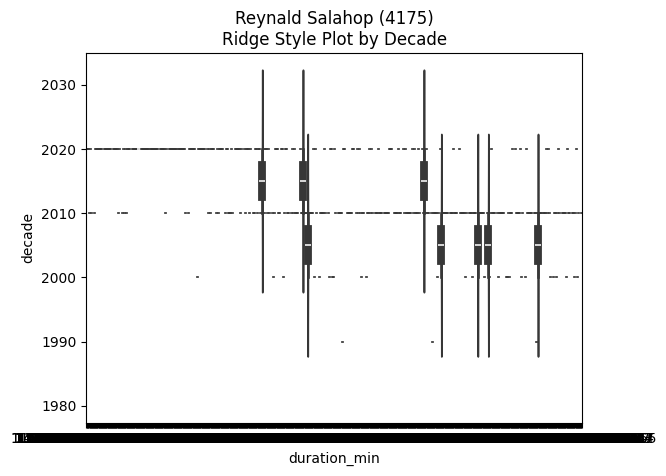

In [29]:
#4
student_name = "Reynald Salahop" 
student_id = "4175" 
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['decade'] = (df['release_date'].dt.year // 10) * 10
sns.violinplot(data=df, x='duration_min', y='decade', palette='coolwarm', scale='width') 
plt.title(f"{student_name} ({student_id})\nRidge Style Plot by Decade") 
plt.show() 

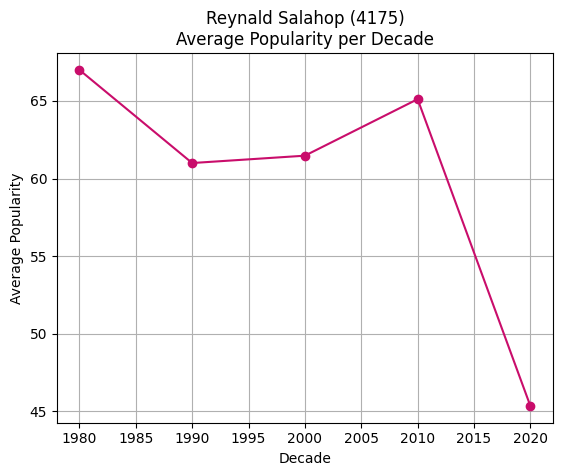

In [15]:
#5
avg_pop = df.groupby('decade')['popularity'].mean() 
avg_pop.plot(kind='line', color=color1, marker='o') 
plt.title(f"{student_name} ({student_id})\nAverage Popularity per Decade") 
plt.xlabel('Decade') 
plt.ylabel('Average Popularity') 
plt.grid(True) 
plt.show() 

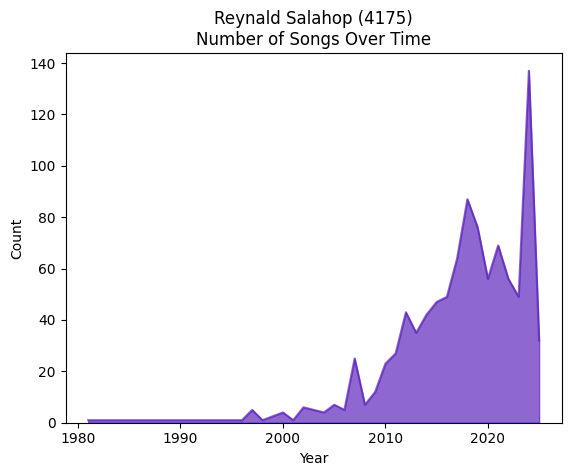

In [ ]:
#6
count_by_year = df['year'].value_counts().sort_index() 
count_by_year.plot(kind='area', color=color2, alpha=0.7) 
plt.title(f"{student_name} ({student_id})\nNumber of Songs Over Time") 
plt.xlabel('Year') 
plt.ylabel('Count') 
plt.show()

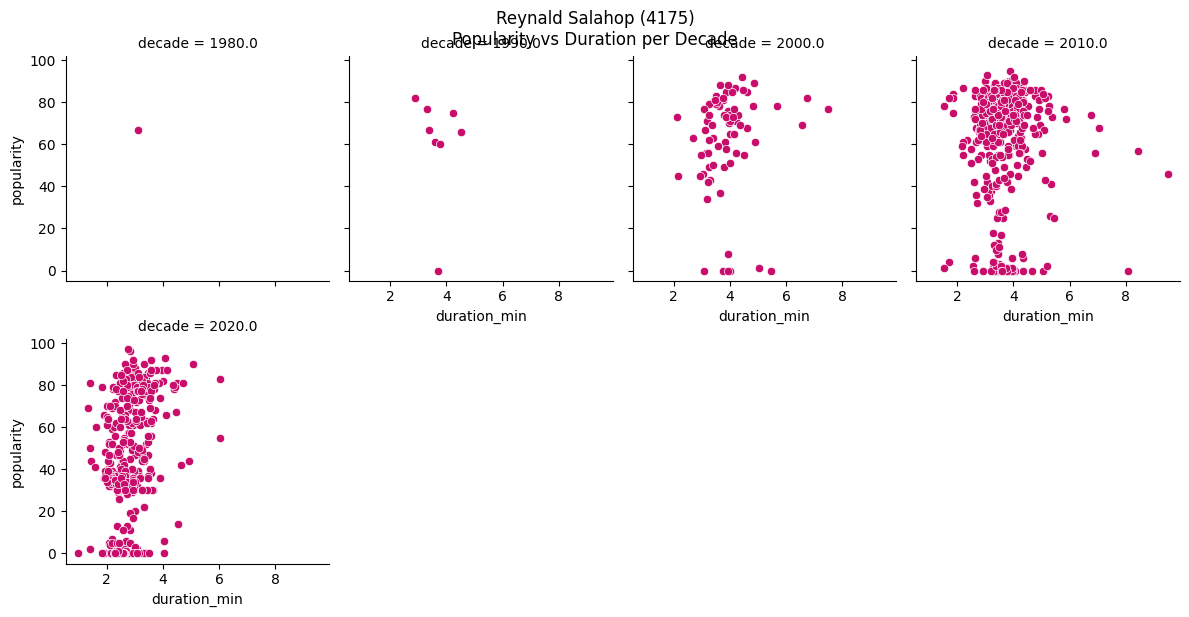

In [16]:
#7
g = sns.FacetGrid(df, col='decade', col_wrap=4, height=3) 
g.map_dataframe(sns.scatterplot, x='duration_min', y='popularity', 
color=color1) 
g.fig.suptitle(f"{student_name} ({student_id})\nPopularity vs Duration per Decade", y=1.02) 
plt.show() 

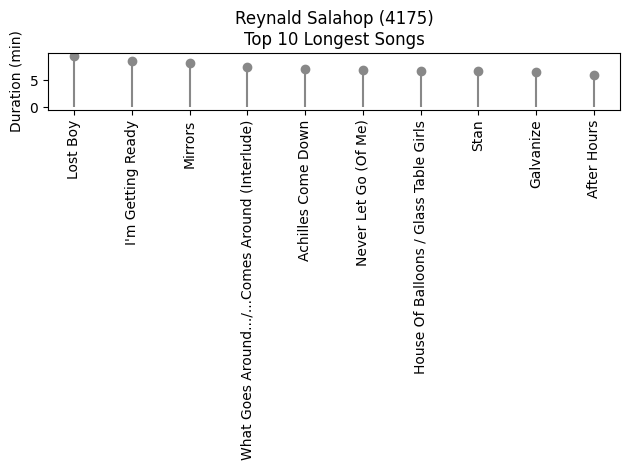

In [ ]:
#8
longest = df.nlargest(10, 'duration_min') 
plt.stem(longest['track_name'], longest['duration_min'], 
linefmt='#888888', markerfmt='o', basefmt=" ") 
plt.xticks(rotation=90) 
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Songs") 
plt.ylabel('Duration (min)') 
plt.tight_layout() 
plt.show() 


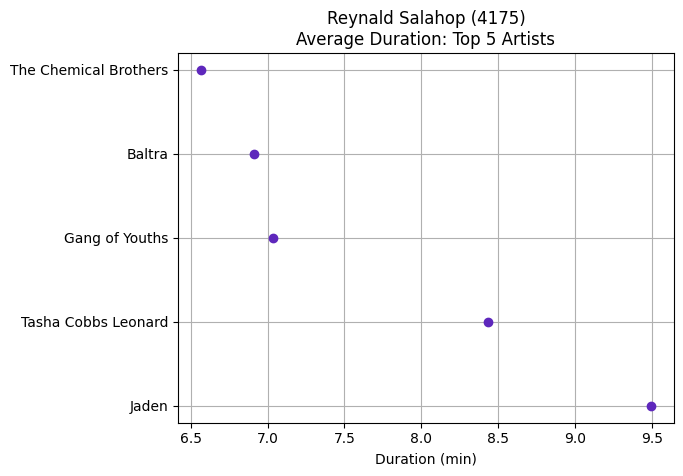

In [ ]:
#9
avg_duration = df.groupby('artist')['duration_min'].mean().nlargest(5) 
plt.plot(avg_duration.values, avg_duration.index, 'o', color=color2) 
plt.title(f"{student_name} ({student_id})\nAverage Duration: Top 5 Artists") 
plt.xlabel('Duration (min)') 
plt.grid(True) 
plt.show()

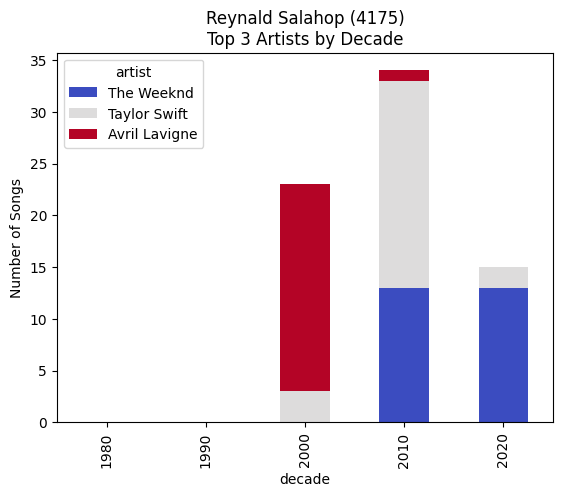

In [ ]:
#10
crosstab = pd.crosstab(df['decade'], df['artist']) 
top3 = df['artist'].value_counts().head(3).index 
crosstab[top3].plot(kind='bar', stacked=True, colormap='coolwarm') 
plt.title(f"{student_name} ({student_id})\nTop 3 Artists by Decade") 
plt.ylabel('Number of Songs') 
plt.show() 

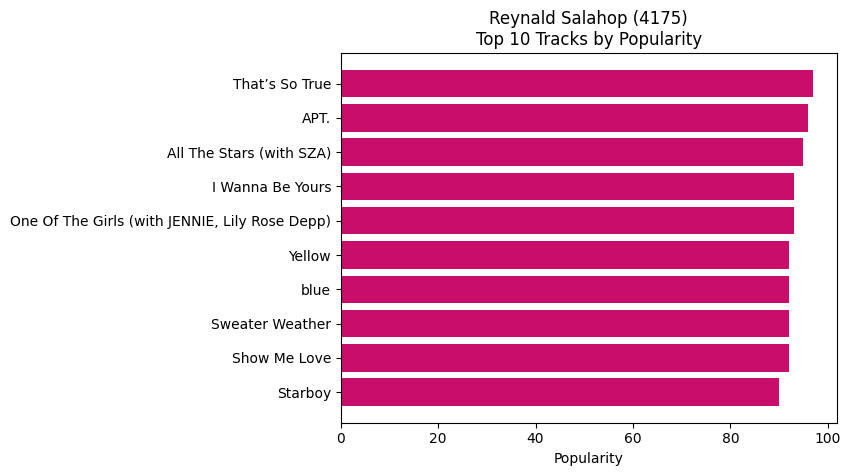

In [17]:
#11
top_tracks = df.nlargest(10, 'popularity')
plt.barh(top_tracks['track_name'], top_tracks['popularity'], color=color1)
plt.xlabel('Popularity')
plt.title(f"{student_name} ({student_id})\nTop 10 Tracks by Popularity")
plt.gca().invert_yaxis()
plt.show()

C:\Users\CLienT\AppData\Local\Temp\ipykernel_6488\107862491.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',
C:\Users\CLienT\AppData\Local\Temp\ipykernel_6488\107862491.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist',


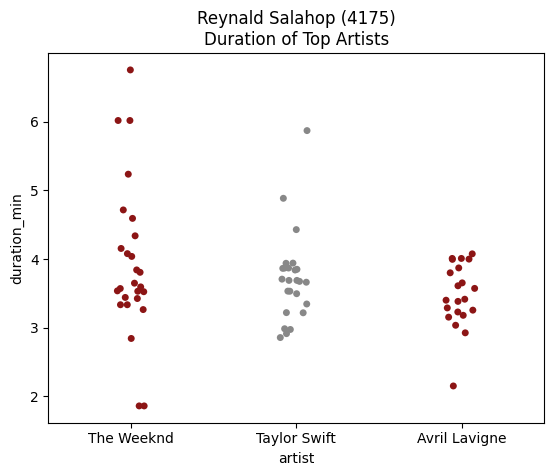

In [ ]:
#12
top_artists = df['artist'].value_counts().head(3).index 
sns.stripplot(data=df[df['artist'].isin(top_artists)], x='artist', 
y='duration_min', palette=['#8C1515', '#888888']) 
plt.title(f"{student_name} ({student_id})\nDuration of Top Artists") 
plt.show()

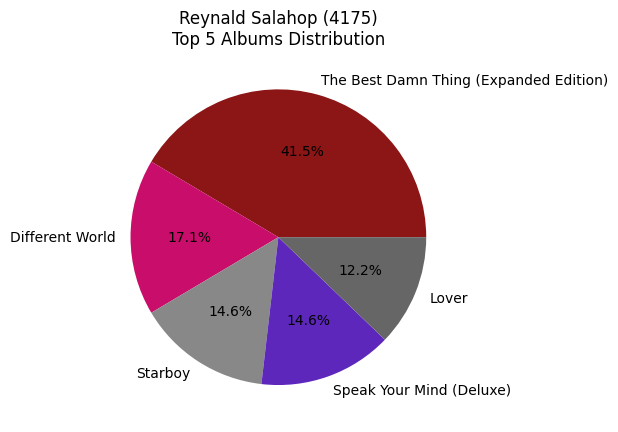

In [ ]:
#13
top_albums = df['album'].value_counts().head(5) 
colors = ['#8C1515', color1, '#888888', color2, '#666666'] 
plt.pie(top_albums, labels=top_albums.index, autopct='%1.1f%%', 
colors=colors) 
plt.title(f"{student_name} ({student_id})\nTop 5 Albums Distribution") 
plt.show()

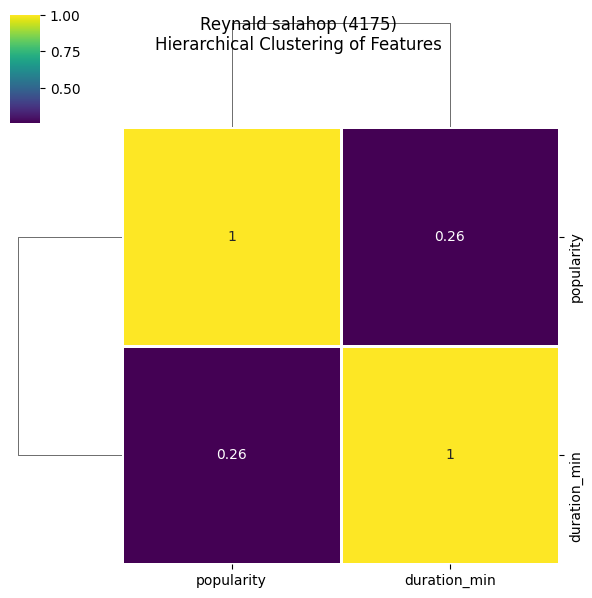

In [2]:
#14
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
#4
student_name = "Reynald salahop" 
student_id = "4175" 

dataset_path = r"C:\Users\CLienT\Documents\COMPROG LAB\spotify_top_1000_tracks.csv"
df = pd.read_csv(dataset_path, encoding="utf-8")
numerical_cols = ['popularity', 'duration_min'] 
df_numeric = df[numerical_cols].dropna() 
sns.clustermap(df_numeric.corr(), annot=True, cmap='viridis', 
linewidths=.75, figsize=(6, 6)) 
plt.suptitle(f"{student_name} ({student_id})\nHierarchical Clustering of Features") 
plt.show() 



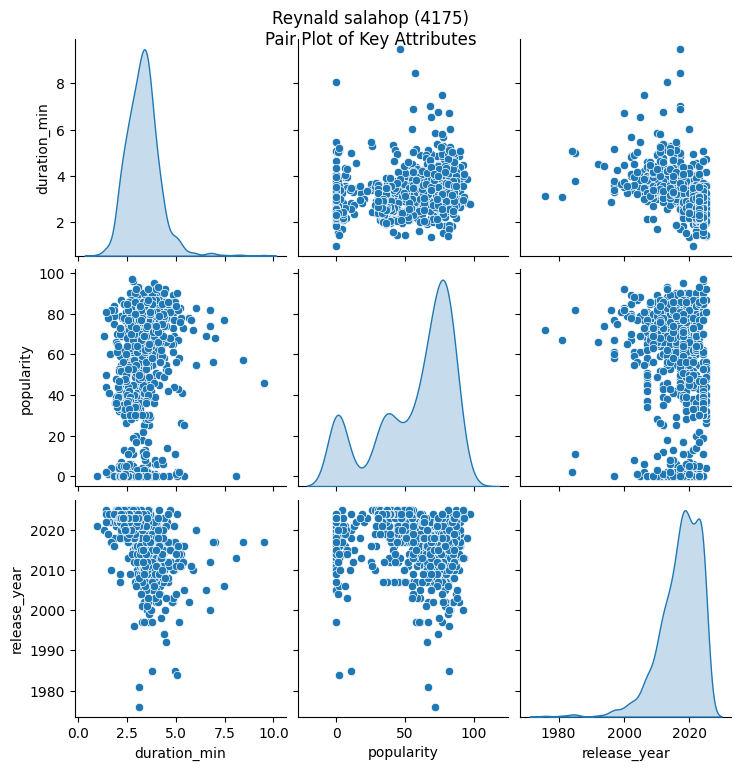

In [14]:
#15
dataset_path = r"C:\Users\CLienT\Documents\COMPROG LAB\spotify_top_1000_tracks.csv"
df = pd.read_csv(dataset_path, encoding="utf-8")
df['release_year'] = pd.to_datetime(df['release_date'], format='mixed').dt.year
sns.pairplot(df[['duration_min', 'popularity', 'release_year']], diag_kind='kde')
plt.suptitle(f"{student_name} ({student_id})\nPair Plot of Key Attributes",y=1.02) 
plt.show() 

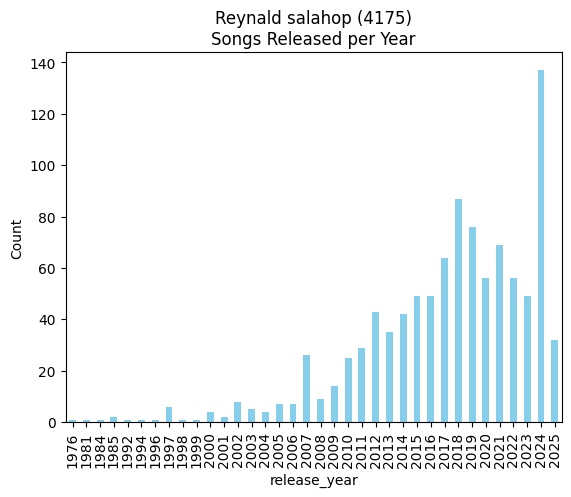

In [17]:
#16
df['release_year'].value_counts().sort_index().plot(kind='bar', 
color='skyblue') 
plt.title(f"{student_name} ({student_id})\nSongs Released per Year") 
plt.ylabel('Count') 
plt.show()

C:\Users\CLienT\AppData\Local\Temp\ipykernel_11136\1804646220.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df.head(50), x='artist', y='popularity',


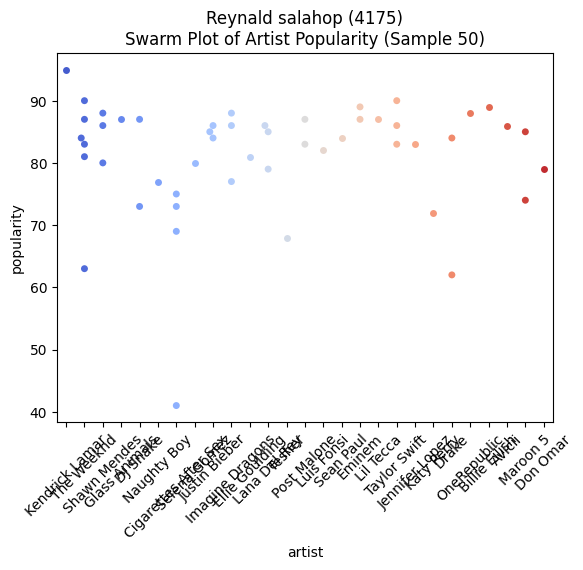

In [18]:
#17
sns.swarmplot(data=df.head(50), x='artist', y='popularity', 
palette='coolwarm') 
plt.title(f"{student_name} ({student_id})\nSwarm Plot of Artist Popularity (Sample 50)") 
plt.xticks(rotation=45) 
plt.show() 

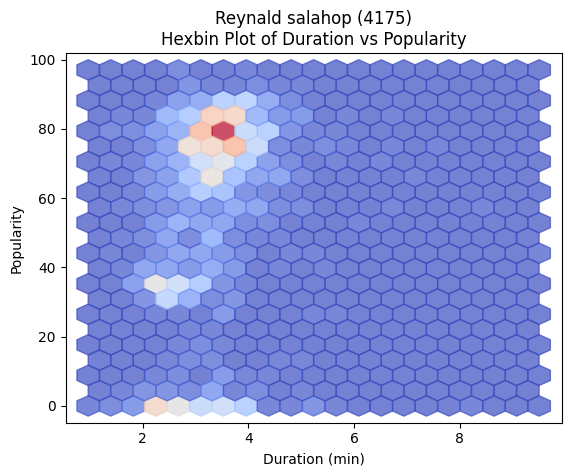

In [19]:
#18
plt.hexbin(df['duration_min'], df['popularity'], gridsize=20, 
cmap='coolwarm', alpha=0.7) 
plt.xlabel('Duration (min)') 
plt.ylabel('Popularity') 
plt.title(f"{student_name} ({student_id})\nHexbin Plot of Duration vs Popularity") 
plt.show()

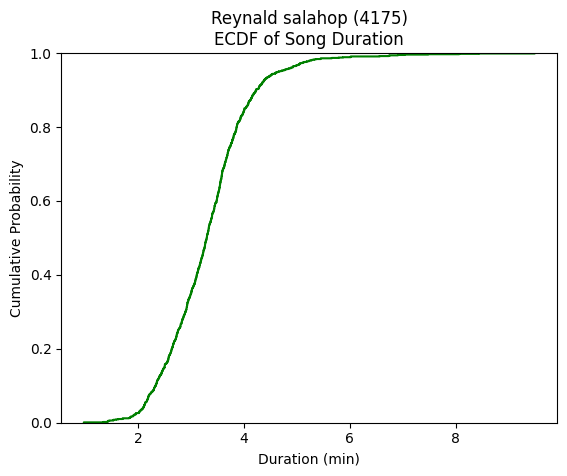

In [21]:
#19
sns.ecdfplot(data=df, x='duration_min', color='green') 
plt.title(f"{student_name} ({student_id})\nECDF of Song Duration") 
plt.xlabel('Duration (min)') 
plt.ylabel('Cumulative Probability') 
plt.show()

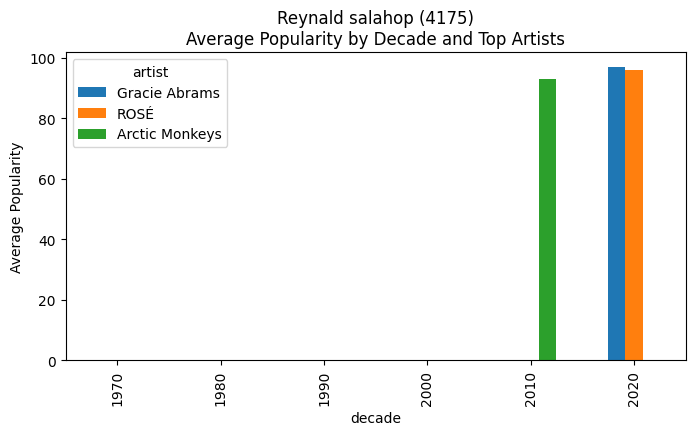

In [23]:
#20
df['decade'] = (df['release_year'] // 10) * 10
avg_artist_decade = df.groupby(['decade', 
'artist'])['popularity'].mean().unstack().fillna(0) 
top3 = df.groupby('artist')['popularity'].mean().nlargest(3).index.tolist()
avg_artist_decade[top3].plot(kind='bar', figsize=(8, 4)) 
plt.title(f"{student_name} ({student_id})\nAverage Popularity by Decade and Top Artists") 
plt.ylabel('Average Popularity') 
plt.show() 